# Questão 4 — Interpretabilidade da CNN

Reutilizamos a CNN treinada na Questão 3 (Fashion-MNIST) e investigamos as representações aprendidas pela rede:

- **4a)** Filtros da primeira camada convolucional
- **4b)** Mapas de ativação de uma camada convolucional intermediária
- **4c)** Acertos e erros de classificação

---
## Configuração inicial

Importações, carregamento do Fashion-MNIST e do modelo já treinado.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Conv2D

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = load_model("models/modelo_cnn.keras")

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,404,224 (5.36 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 936,022 (3.57 MB)

In [4]:
nomes_classes = [
    "Camiseta/Top",
    "Calça",
    "Suéter",
    "Vestido",
    "Casaco",
    "Sandália",
    "Camisa",
    "Tênis",
    "Bolsa",
    "Bota"
]

---
## 4a) Filtros da primeira camada convolucional

Localizamos todas as camadas `Conv2D`, selecionamos a **primeira** delas e visualizamos os 32 filtros aprendidos (kernels 3×3).


In [5]:
camadas_conv = [
    camada for camada in model.layers
    if isinstance(camada, Conv2D)
]

for i, layer in enumerate(camadas_conv):
    print(
        f"{i}: {layer.name} | "
        f"saída: {layer.output.shape}"
    )

Primeira_Rede_Conv = camadas_conv[0]

0: conv2d_33 | saída: (None, 28, 28, 32)
1: conv2d_34 | saída: (None, 28, 28, 32)
2: conv2d_35 | saída: (None, 14, 14, 64)
3: conv2d_36 | saída: (None, 14, 14, 64)


In [ ]:
filters, biases = Primeira_Rede_Conv.get_weights()

print("Formato dos filtros:", filters.shape)
print("Formato dos bias:", biases.shape)

Formato dos filtros: (3, 3, 1, 32)
Formato dos bias: (32,)


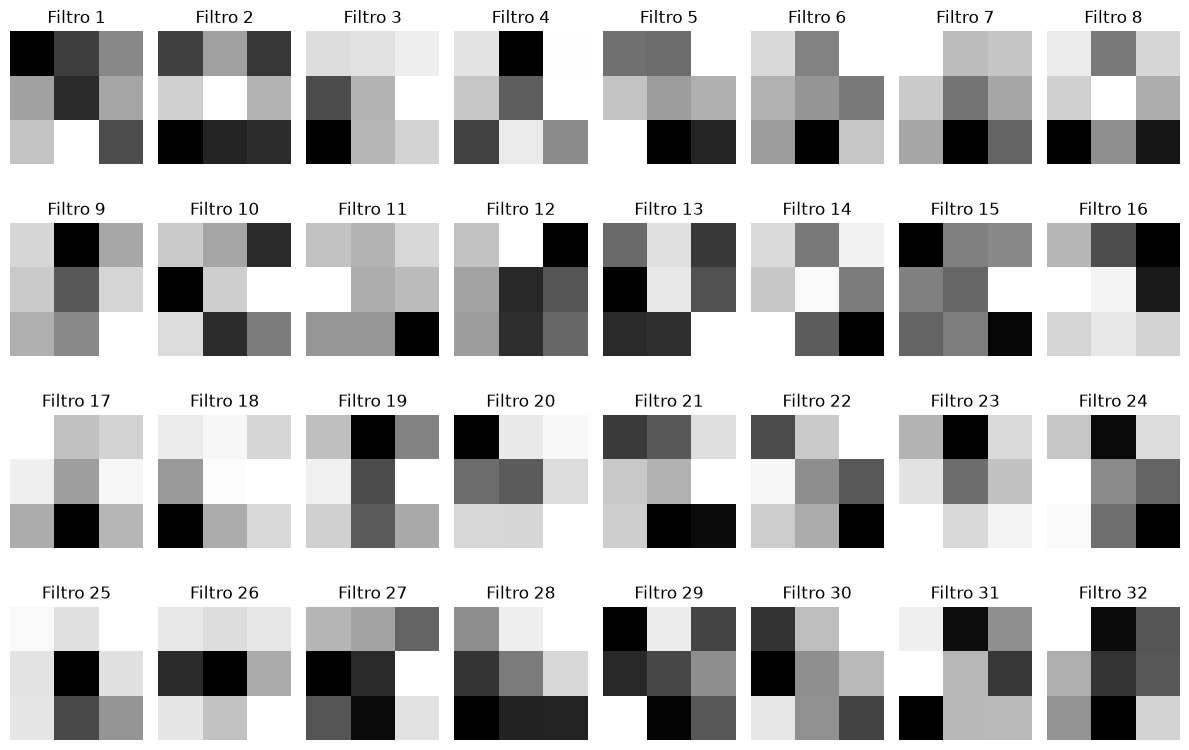

In [ ]:
#normaliza os pesos para o intervalo [0, 1] apenas para visualização
filters_normalized = (
    filters - filters.min()
) / (filters.max() - filters.min() + 1e-8)

num_filters = filters.shape[-1]
num_cols = 8
num_rows = int(np.ceil(num_filters / num_cols))

plt.figure(figsize=(12, num_rows * 2))

for i in range(num_filters):
    plt.subplot(num_rows, num_cols, i + 1)

    filter_image = filters_normalized[:, :, 0, i]

    plt.imshow(filter_image, cmap="gray")
    plt.title(f"Filtro {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Descrição qualitativa dos filtros.**
A primeira camada possui 32 filtros de dimensão 3×3 com um único canal de entrada (imagens em tons de cinza). Por serem pequenos, eles funcionam como **detectores locais de baixo nível**:

- Vários filtros apresentam uma divisão clara entre região clara e escura (transições no sentido horizontal, vertical ou diagonal), comportando-se como **detectores de borda e de gradiente de intensidade** em diferentes orientações.
- Alguns filtros são mais uniformes, com pouca variação entre os pixels, atuando de forma próxima a um **operador de média/suavização**, sensível ao nível geral de brilho da vizinhança.
- Outros concentram o contraste em um canto ou pixel central, aproximando-se de **detectores de ponto/quina**.

Como esta é a camada mais rasa, os padrões ainda são genéricos (bordas e contrastes locais); as combinações que dão origem a texturas e partes de objetos surgem nas camadas mais profundas.


---
## 4b) Mapas de ativação (camada intermediária)

Construímos um modelo auxiliar que expõe a saída de uma camada convolucional **intermediária** (`camadas_conv[2]`) e observamos como ela responde a pelo menos 5 imagens do conjunto de teste, de classes distintas.


In [ ]:
camada_intermediaria = camadas_conv[2]

modelo_ativacoes = Model(
    inputs=model.inputs,
    outputs=camada_intermediaria.output
)

print("Camada analisada:", camada_intermediaria.name)
print("Formato da saída:", camada_intermediaria.output.shape)

Camada analisada: conv2d_35
Formato da saída: (None, 14, 14, 64)


In [ ]:
# 5 classes diferentes: Camiseta/Top, Calça, Vestido, Tênis e Bota
classes_escolhidas = [0, 1, 3, 7, 9]

indices_escolhidos = [
    np.where(y_test == classe)[0][0]
    for classe in classes_escolhidas
]

imagens_escolhidas = X_test[indices_escolhidos]
rotulos_escolhidos = y_test[indices_escolhidos]

print("Índices:", indices_escolhidos)
print("Classes:", rotulos_escolhidos)

Índices: [np.int64(19), np.int64(2), np.int64(13), np.int64(9), np.int64(0)]
Classes: [0 1 3 7 9]


In [ ]:
ativacoes = modelo_ativacoes.predict(
    imagens_escolhidas,
    verbose=0
)

print("Formato das ativações:", ativacoes.shape)

Formato das ativações: (5, 14, 14, 64)


### Mapas mais ativados por imagem

Para cada imagem, exibimos a original e os 12 mapas de ativação com maior ativação média, indicando o índice do mapa e o valor médio de ativação.


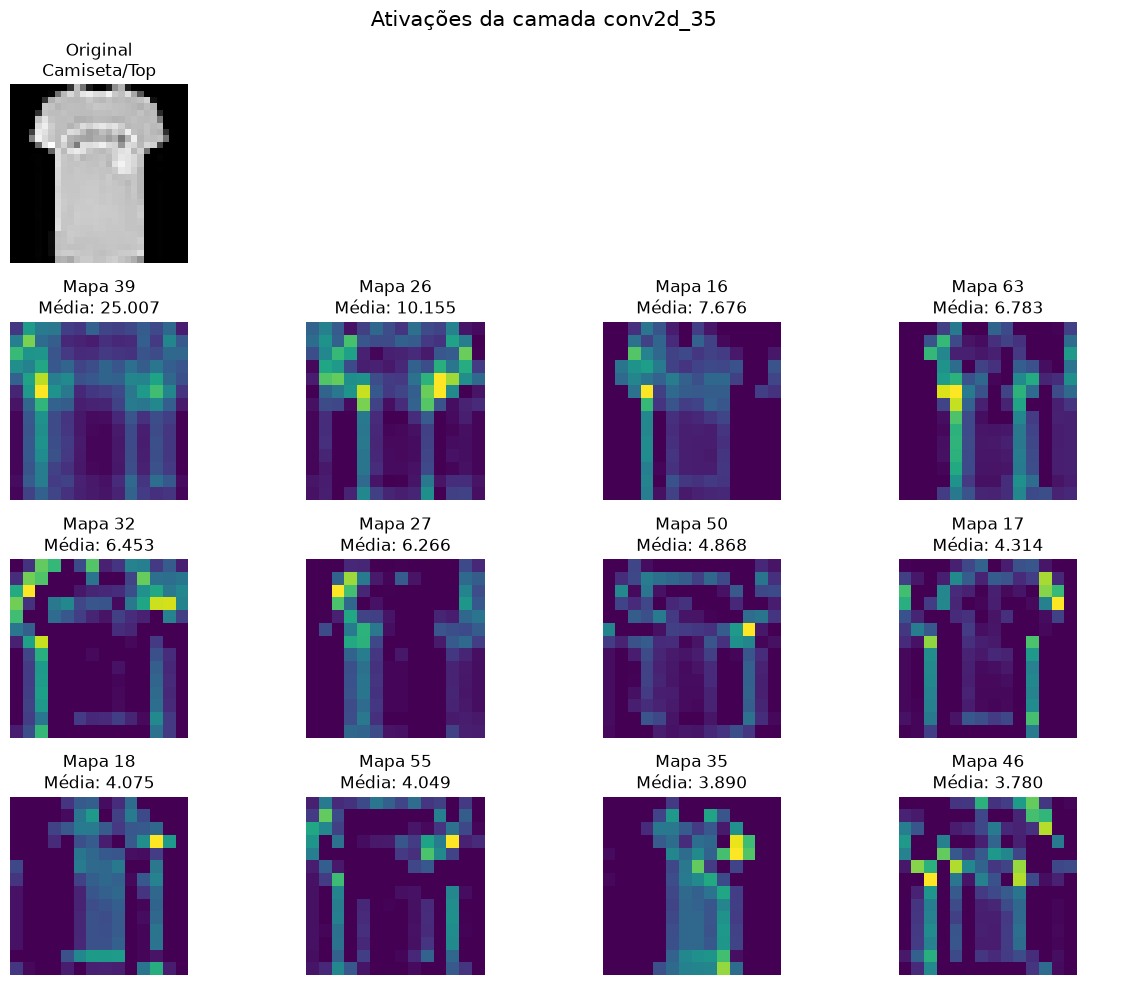

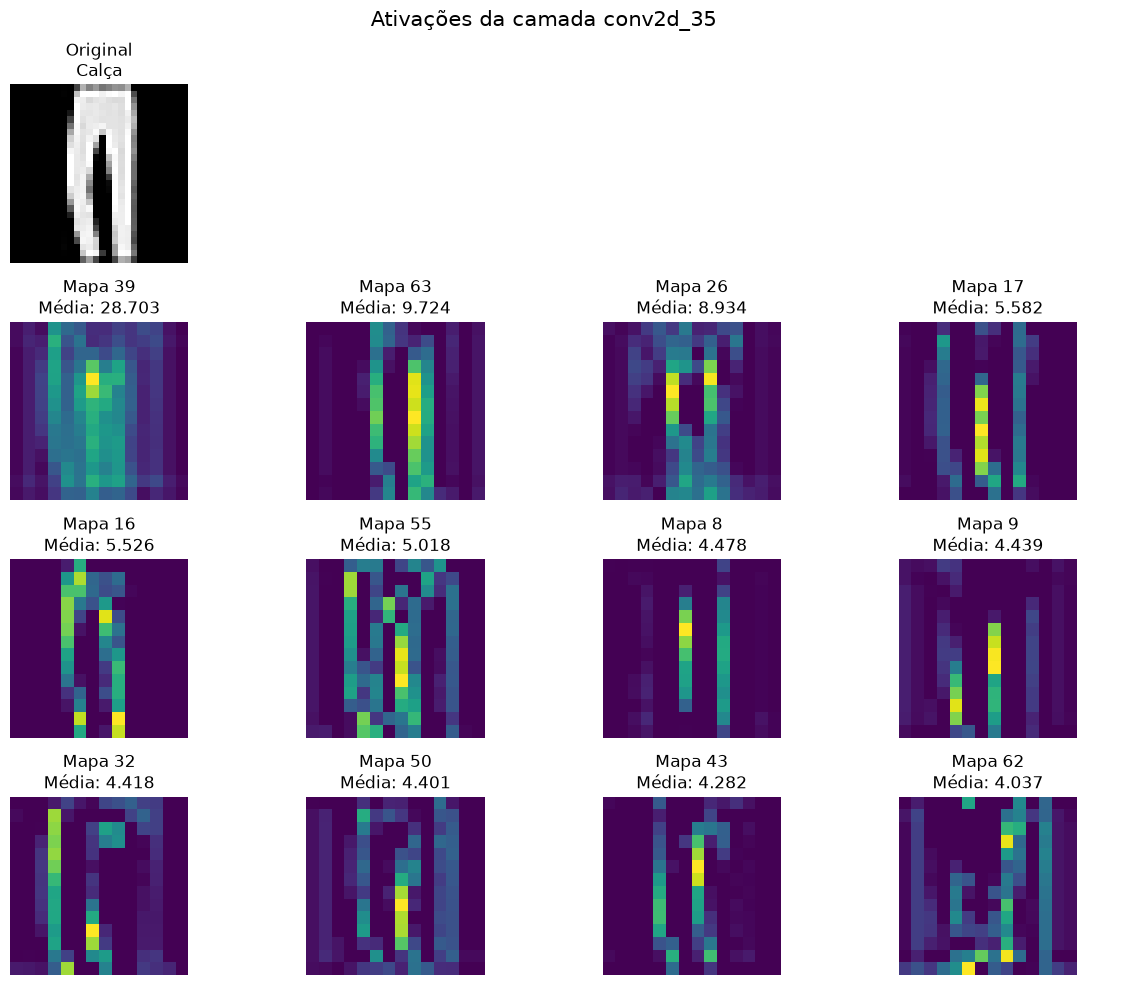

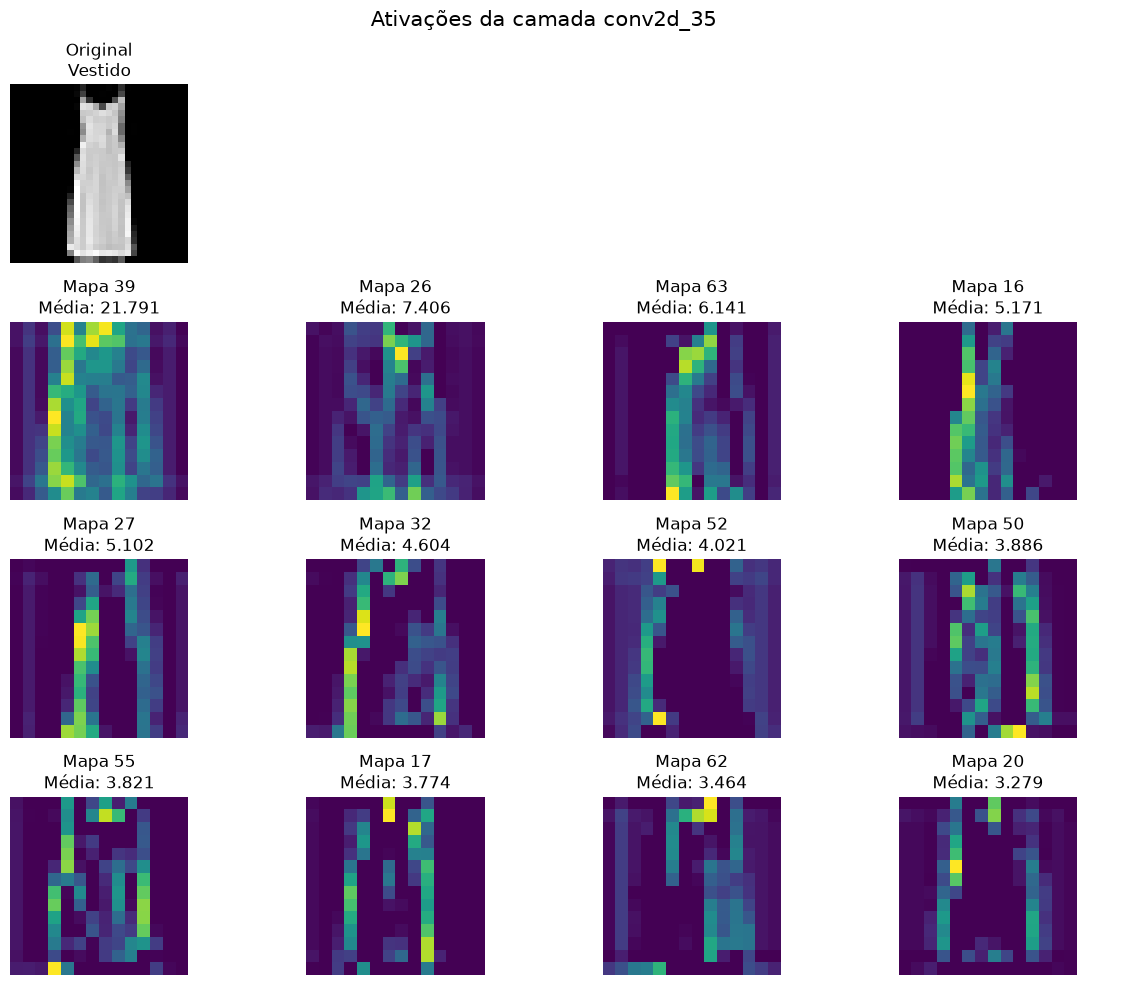

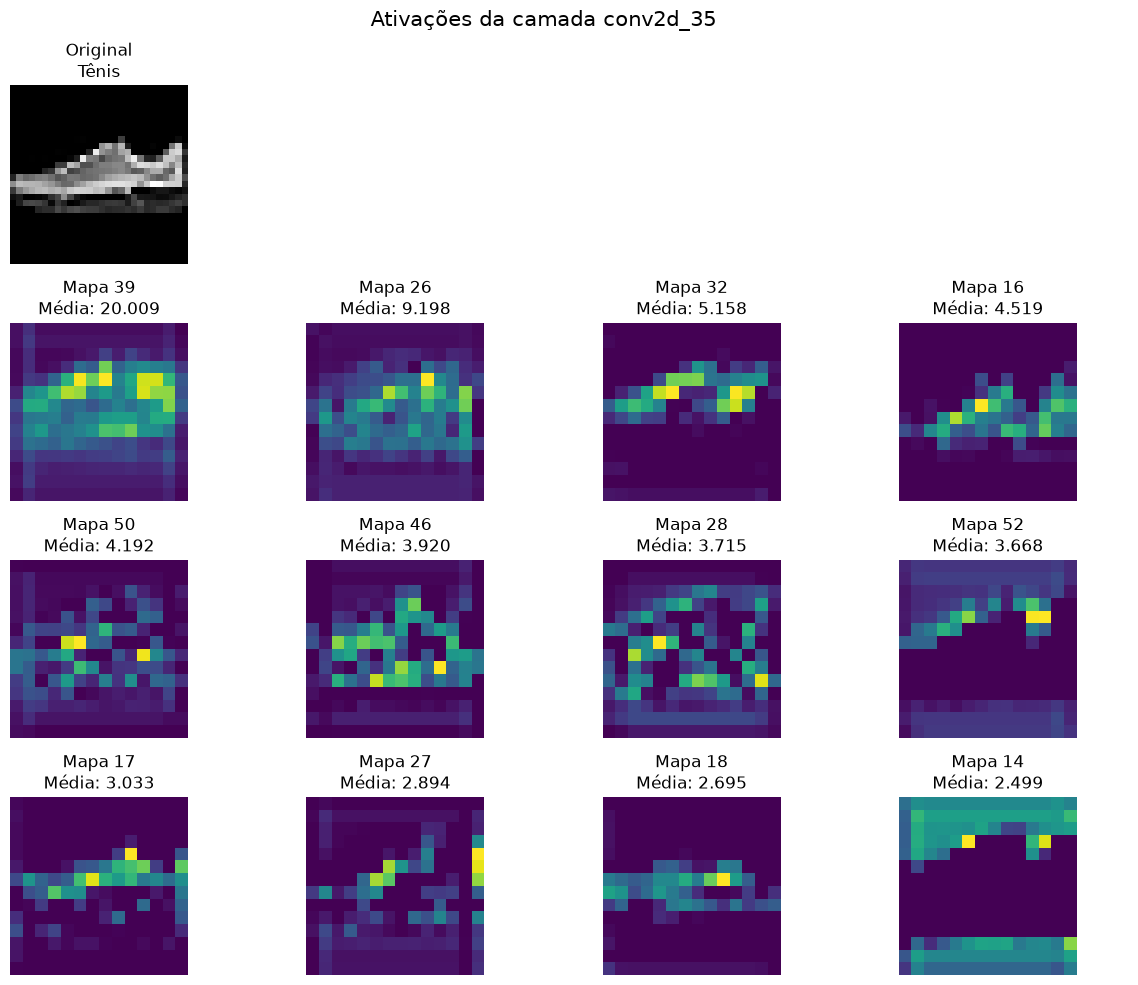

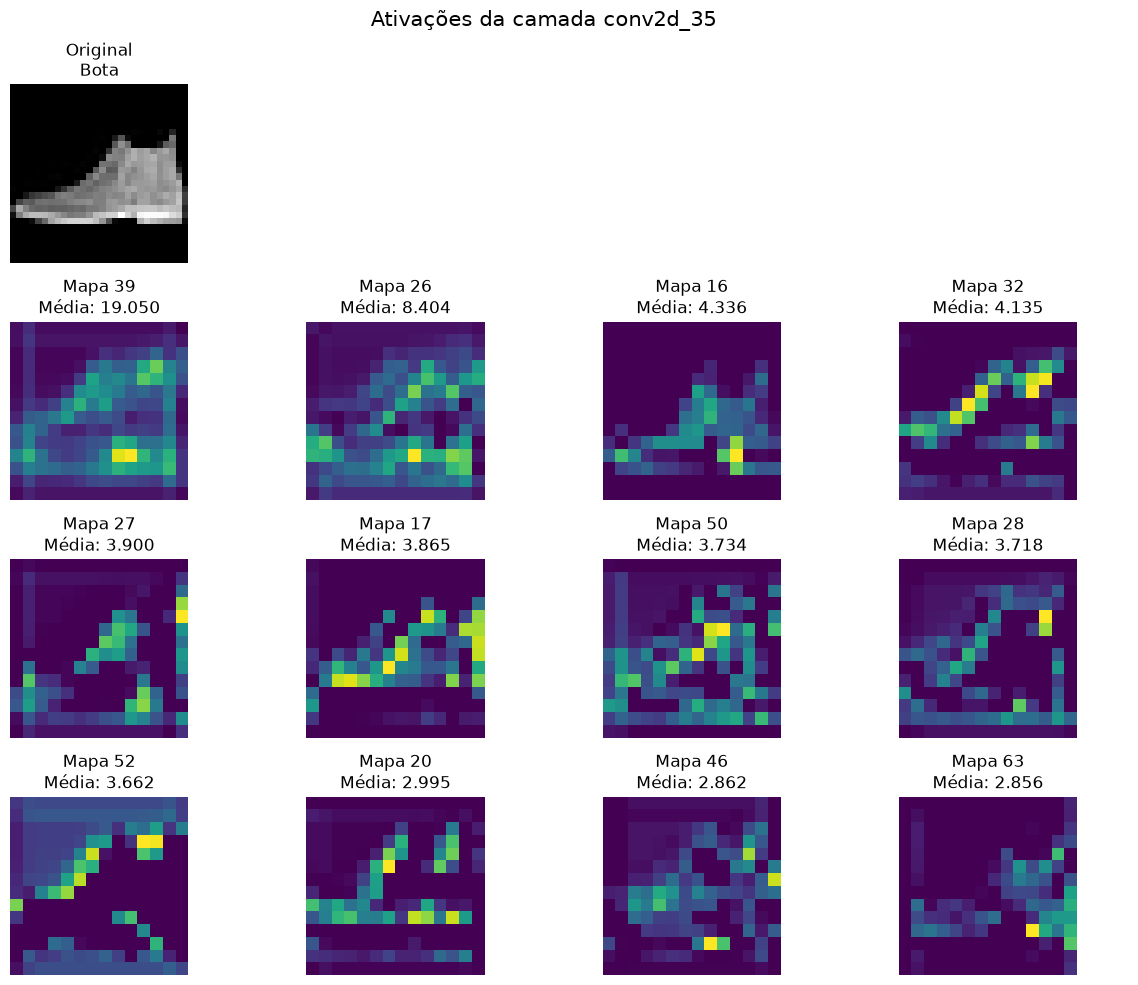

In [ ]:
quantidade_mapas = 12
numero_colunas = 4
nomes_classes = [
    "Camiseta/Top",
    "Calça",
    "Suéter",
    "Vestido",
    "Casaco",
    "Sandália",
    "Camisa",
    "Tênis",
    "Bolsa",
    "Bota"
]
for i in range(len(imagens_escolhidas)):
    imagem = imagens_escolhidas[i]
    ativacao_imagem = ativacoes[i]

    # Média de cada mapa de ativação
    medias = ativacao_imagem.mean(axis=(0, 1))

    # Índices dos mapas com maiores ativações médias
    mapas_mais_ativos = np.argsort(
        medias
    )[-quantidade_mapas:][::-1]

    numero_linhas_mapas = int(
        np.ceil(quantidade_mapas / numero_colunas)
    )

    numero_linhas_total = numero_linhas_mapas + 1

    plt.figure(
        figsize=(12, numero_linhas_total * 2.5)
    )

    # Imagem original
    plt.subplot(
        numero_linhas_total,
        numero_colunas,
        1
    )

    plt.imshow(
        imagem.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Original\n"
        f"{nomes_classes[rotulos_escolhidos[i]]}"
    )

    plt.axis("off")

    # Deixa as posições restantes da primeira linha vazias
    for posicao in range(2, numero_colunas + 1):
        plt.subplot(
            numero_linhas_total,
            numero_colunas,
            posicao
        )
        plt.axis("off")

    # Mapas de ativação
    for j, indice_mapa in enumerate(mapas_mais_ativos):
        mapa = ativacao_imagem[:, :, indice_mapa]

        plt.subplot(
            numero_linhas_total,
            numero_colunas,
            numero_colunas + j + 1
        )

        plt.imshow(
            mapa,
            cmap="viridis"
        )

        plt.title(
            f"Mapa {indice_mapa}\n"
            f"Média: {medias[indice_mapa]:.3f}"
        )

        plt.axis("off")

    plt.suptitle(
        f"Ativações da camada {camada_intermediaria.name}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

### Ativação média sobreposta à imagem

Para localizar *onde* a rede mais responde, calculamos a média de todos os canais da camada, redimensionamos para 28×28 e sobrepomos à imagem original (mapa de calor).


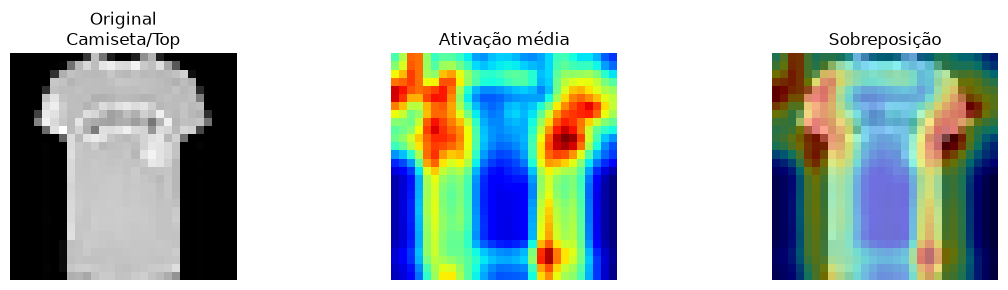

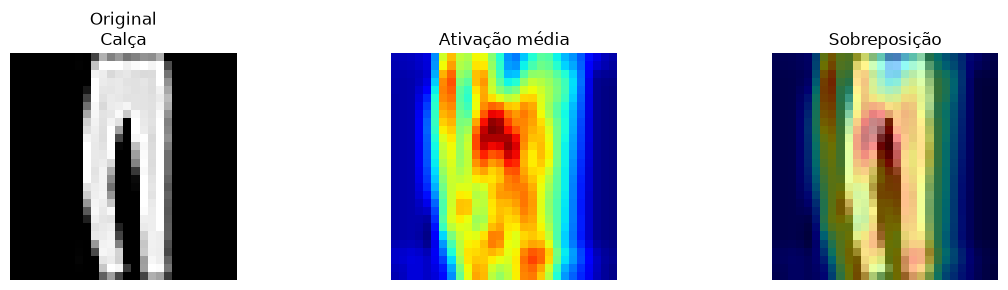

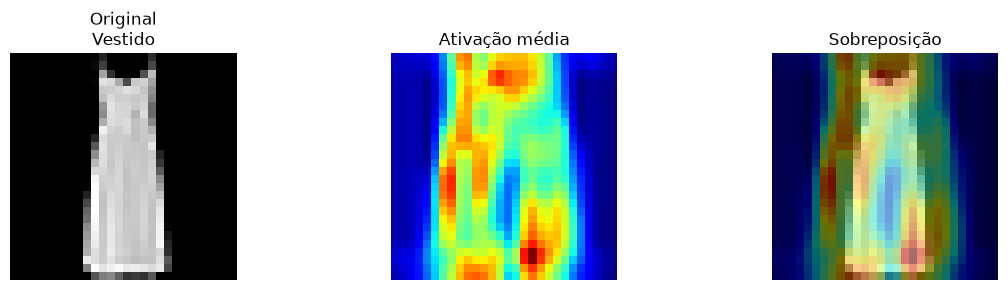

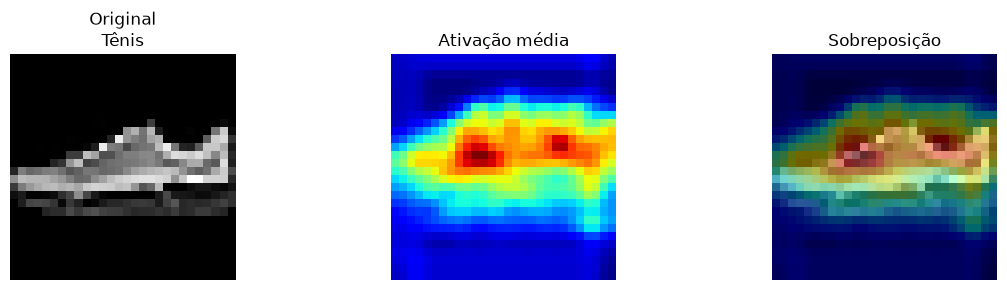

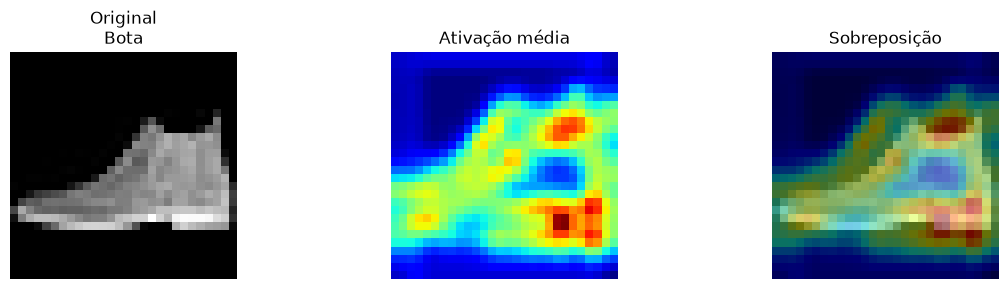

In [ ]:
for i in range(len(imagens_escolhidas)):
    imagem = imagens_escolhidas[i]
    ativacao_imagem = ativacoes[i]

    # Média de todos os mapas
    mapa_medio = ativacao_imagem.mean(axis=-1)

    # Redimensiona para 28 × 28
    mapa_redimensionado = tf.image.resize(
        mapa_medio[..., np.newaxis],
        size=imagem.shape[:2]
    ).numpy().squeeze()

    # Normalização entre 0 e 1
    mapa_redimensionado = (
        mapa_redimensionado
        - mapa_redimensionado.min()
    ) / (
        mapa_redimensionado.max()
        - mapa_redimensionado.min()
        + 1e-8
    )

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(imagem.squeeze(), cmap="gray")
    plt.title(
        f"Original\n"
        f"{nomes_classes[rotulos_escolhidos[i]]}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(
        mapa_redimensionado,
        cmap="jet"
    )
    plt.title("Ativação média")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(
        imagem.squeeze(),
        cmap="gray"
    )
    plt.imshow(
        mapa_redimensionado,
        cmap="jet",
        alpha=0.45
    )
    plt.title("Sobreposição")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 4c) Acertos e erros de classificação

Geramos as predições da CNN para todo o conjunto de teste, garantimos que a saída esteja em forma de probabilidade e apresentamos exemplos **corretamente** e **incorretamente** classificados, com classe verdadeira, classe predita e a probabilidade associada.


In [ ]:
saidas = model.predict(X_test, verbose=0)

print("Formato da saída:", saidas.shape)

Formato da saída: (10000, 10)


In [14]:
somas = saidas.sum(axis=1)

parecem_probabilidades = (
    np.all(saidas >= 0)
    and np.all(saidas <= 1)
    and np.allclose(somas, 1.0, atol=1e-3)
)

if parecem_probabilidades:
    
    probabilidades = saidas
    
else:
    probabilidades = tf.nn.softmax(
        saidas,
        axis=1
    ).numpy()

In [15]:
classes_preditas = np.argmax(
    probabilidades,
    axis=1
)

probabilidades_preditas = np.max(
    probabilidades,
    axis=1
)

In [16]:
acuracia = np.mean(
    classes_preditas == y_test
)

print(
    f"Acurácia no conjunto de teste: "
    f"{acuracia * 100:.2f}%"
)

Acurácia no conjunto de teste: 76.49%


In [17]:
indices_corretos = np.where(
    classes_preditas == y_test
)[0]

indices_errados = np.where(
    classes_preditas != y_test
)[0]

print("Quantidade de acertos:", len(indices_corretos))
print("Quantidade de erros:", len(indices_errados))

Quantidade de acertos: 7649
Quantidade de erros: 2351


In [18]:
rng = np.random.default_rng(42)

exemplos_corretos = rng.choice(
    indices_corretos,
    size=5,
    replace=False
)

exemplos_errados = rng.choice(
    indices_errados,
    size=5,
    replace=False
)

In [19]:
def visualizar_classificacoes(
    indices,
    titulo,
    x_test,
    y_test,
    classes_preditas,
    probabilidades_preditas,
    nomes_classes
):
    quantidade = len(indices)

    plt.figure(figsize=(15, 4))

    for posicao, indice in enumerate(indices):
        classe_real = y_test[indice]
        classe_predita = classes_preditas[indice]
        probabilidade = probabilidades_preditas[indice]

        plt.subplot(1, quantidade, posicao + 1)

        plt.imshow(
            x_test[indice].squeeze(),
            cmap="gray"
        )

        plt.title(
            f"Real: {nomes_classes[classe_real]}\n"
            f"Predita: {nomes_classes[classe_predita]}\n"
            f"Prob.: {probabilidade * 100:.2f}%"
        )

        plt.axis("off")

    plt.suptitle(titulo, fontsize=15)
    plt.tight_layout()
    plt.show()

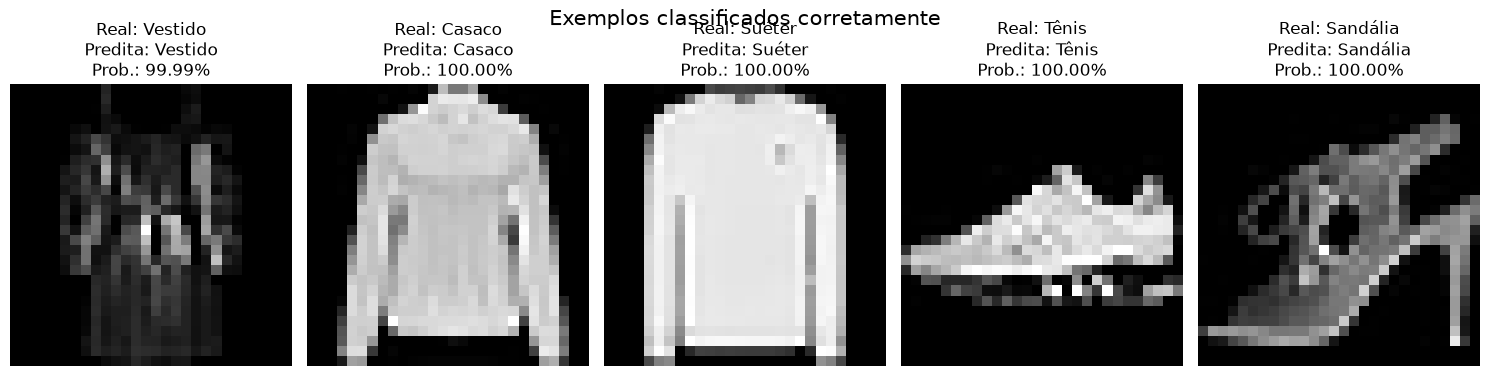

In [20]:
visualizar_classificacoes(
    indices=exemplos_corretos,
    titulo="Exemplos classificados corretamente",
    x_test=X_test,
    y_test=y_test,
    classes_preditas=classes_preditas,
    probabilidades_preditas=probabilidades_preditas,
    nomes_classes=nomes_classes
)

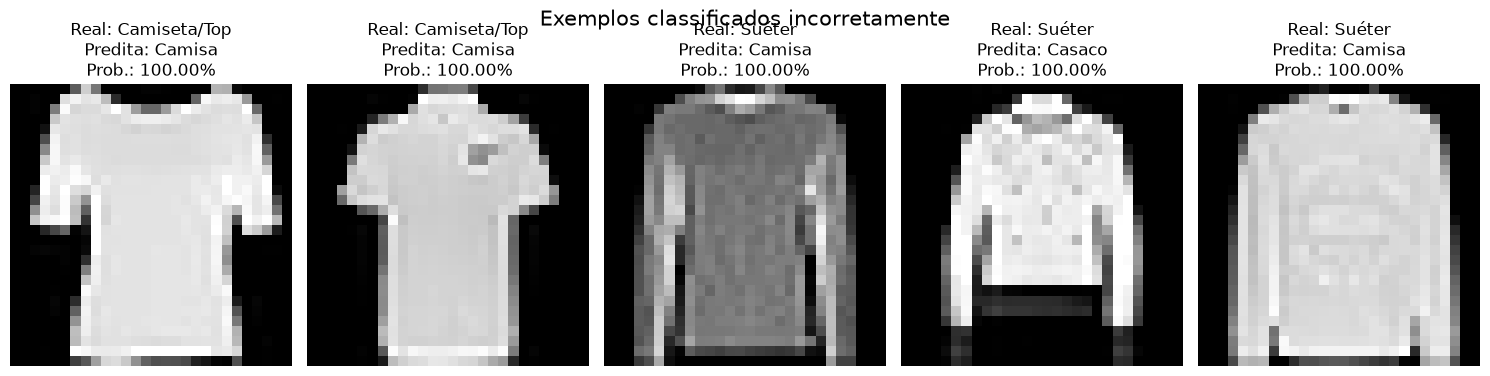

In [21]:
visualizar_classificacoes(
    indices=exemplos_errados,
    titulo="Exemplos classificados incorretamente",
    x_test=X_test,
    y_test=y_test,
    classes_preditas=classes_preditas,
    probabilidades_preditas=probabilidades_preditas,
    nomes_classes=nomes_classes
)

**Leitura dos resultados.**
Entre os acertos, a rede tende a atribuir alta probabilidade à classe correta em peças com silhueta bem definida. Já nos erros aparecem as confusões típicas do Fashion-MNIST entre categorias visualmente semelhantes (por exemplo, Camiseta/Top × Camisa × Casaco/Suéter, ou Sandália × Tênis × Bota), muitas vezes com probabilidade elevada mesmo quando a predição está errada — sinal de que a rede se apoia em contornos gerais que essas classes compartilham.
